# Configuration-Conditional Sensor Calibration

This notebook prepares a small offline calibration corpus, fits the current two-level spectral calibration model, stores the resulting artifact, and inspects the learned persistent laws.

The key architectural boundary is:

- `campaign_calibration.py` handles repository I/O, metadata parsing, alignment, and campaign diagnostics.
- `spectral_calibration.py` holds the numerical model and optimizer.
- `artifacts.py` persists the fitted result for later deployment.

In [ ]:
# Modify this list to exclude specific nodes from the WHOLE analysis (Train + Deploy).
EXCLUDED_NODES = ["Node9","Node10"]  # Node 9: Is on another location (non-comparable with others), Node 10: Seems to be broken

In [1]:
from __future__ import annotations

from pathlib import Path
import sys

from IPython.display import display
import matplotlib.pyplot as plt
import pandas as pd


def resolve_repo_root() -> Path:
    """Return the repository root regardless of the current notebook cwd."""

    for candidate in (Path.cwd().resolve(), *Path.cwd().resolve().parents):
        if (candidate / "measurement_calibration").exists() and (candidate / "notebooks").exists():
            return candidate
    raise RuntimeError("Could not resolve the repository root from the notebook cwd")


REPO_ROOT = resolve_repo_root()
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from measurement_calibration import (
    DEFAULT_CAMPAIGNS_DATA_DIR,
    DEFAULT_CONFIGURATION_CONDITIONAL_MODELS_DIR,
    FrequencyBasisConfig,
    PersistentModelConfig,
    TwoLevelFitConfig,
    build_corpus_calibration_output_dir,
    evaluate_persistent_calibration,
    fit_and_save_calibration_corpus_model,
    load_two_level_calibration_artifact,
    power_linear_to_db,
    prepare_calibration_corpus,
)

CAMPAIGNS_ROOT = REPO_ROOT / DEFAULT_CAMPAIGNS_DATA_DIR
MODELS_ROOT = REPO_ROOT / DEFAULT_CONFIGURATION_CONDITIONAL_MODELS_DIR
TRAINING_CAMPAIGN_LABELS = ("MeasurementCalibration", "test-calibration")
MODEL_LABEL = "measurement_demo_corpus"

# Keep the demo deterministic and lightweight while still exercising the real model.
BASIS_CONFIG = FrequencyBasisConfig(
    n_gain_basis=10,
    n_floor_basis=8,
    n_variance_basis=8,
    spline_degree=3,
)
MODEL_CONFIG = PersistentModelConfig(
    sensor_embedding_dim=4,
    configuration_latent_dim=4,
)
FIT_CONFIG = TwoLevelFitConfig(
    n_outer_iterations=8,
    n_gradient_steps=20,
    learning_rate=0.03,
    sigma_min=1.0e-8,
    adaptive_variance_floor_ratio=1.0e-4,
    select_best_outer_iterate=True,
    early_stopping_patience=5,
    divergence_tolerance_ratio=10.0,
    refresh_campaign_variance_from_residuals=True,
    variance_refresh_ridge=1.0e-6,
)

pd.set_option("display.max_columns", 32)
pd.set_option("display.max_rows", 32)

REPO_ROOT

PosixPath('/home/marti/Code/MeasurementCalibration')

## Prepare The Offline Corpus

The preparation step is a pure orchestration boundary: it loads each campaign, aligns timestamps, ranks sensors for the reliable-sensor annotation, parses `metadata.csv`, and converts the aligned PSD tensors to linear power for the numerical core.

In [2]:
preparation = prepare_calibration_corpus(
    campaign_labels=TRAINING_CAMPAIGN_LABELS,
    campaigns_root=CAMPAIGNS_ROOT,
)

campaign_rows = []
for prepared_campaign in preparation.prepared_campaigns:
    configuration = prepared_campaign.campaign.configuration
    campaign_rows.append(
        {
            "campaign_label": prepared_campaign.campaign_label,
            "sensor_ids": ", ".join(prepared_campaign.campaign.sensor_ids),
            "n_sensors": prepared_campaign.campaign.n_sensors,
            "n_records": prepared_campaign.campaign.n_acquisitions,
            "n_frequencies": prepared_campaign.campaign.n_frequencies,
            "reliable_sensor_id": prepared_campaign.reliable_sensor_id,
            "distribution_outliers": ", ".join(prepared_campaign.distribution_outlier_sensor_ids) or "-",
            "central_freq_MHz": configuration.central_frequency_hz / 1.0e6,
            "span_MHz": configuration.span_hz / 1.0e6,
            "rbw_kHz": configuration.resolution_bandwidth_hz / 1.0e3,
            "acquisition_interval_s": configuration.acquisition_interval_s,
            "antenna_amp": configuration.antenna_amplifier_enabled,
        }
    )

campaign_frame = pd.DataFrame(campaign_rows).sort_values("campaign_label")
display(campaign_frame)

preparation.corpus.sensor_ids

,campaign_label,sensor_ids,n_sensors,n_records,n_frequencies,reliable_sensor_id,distribution_outliers,central_freq_MHz,span_MHz,rbw_kHz,acquisition_interval_s,antenna_amp
0,MeasurementCalibration,"Node1, Node2, Node3, Node5, Node9",5,179,4096,Node2,"Node1, Node9",98.0,20.0,10.0,120.0,True
1,test-calibration,"Node1, Node10, Node2, Node3",4,4,4096,Node3,Node10,98.0,20.0,10.0,120.0,True


('Node1', 'Node10', 'Node2', 'Node3', 'Node5', 'Node9')

## Fit And Store The Model

The saved artifact is the deployment boundary. It contains the persistent model parameters, campaign summaries, optimizer diagnostics, and provenance so later notebooks can reload the exact result instead of reconstructing it informally.

In [3]:
output_dir = build_corpus_calibration_output_dir(
    model_label=MODEL_LABEL,
    models_root=MODELS_ROOT,
)

fit_result = fit_and_save_calibration_corpus_model(
    preparation=preparation,
    output_dir=output_dir,
    basis_config=BASIS_CONFIG,
    model_config=MODEL_CONFIG,
    fit_config=FIT_CONFIG,
)
loaded_artifact = load_two_level_calibration_artifact(output_dir)

training_summary = pd.DataFrame(
    [
        {
            "model_dir": str(output_dir.relative_to(REPO_ROOT)),
            "n_registered_sensors": len(fit_result.result.sensor_ids),
            "n_campaigns": len(fit_result.preparation.prepared_campaigns),
            "n_objective_steps": len(fit_result.result.objective_history),
            "selected_outer_iteration": fit_result.result.fit_diagnostics.selected_outer_iteration,
            "selected_objective_value": fit_result.result.fit_diagnostics.selected_objective_value,
            "final_objective_value": fit_result.result.fit_diagnostics.final_objective_value,
            "terminated_early": fit_result.result.fit_diagnostics.terminated_early,
            "termination_reason": fit_result.result.fit_diagnostics.termination_reason,
            "selected_from_best_iterate": fit_result.result.fit_diagnostics.selected_from_best_iterate,
            "effective_variance_floor_power2": fit_result.result.effective_variance_floor_power2,
            "fit_duration_s": fit_result.fit_duration_s,
        }
    ]
)
display(training_summary)
display(pd.read_csv(loaded_artifact.sensor_summary_path).sort_values("sensor_id"))

output_dir.relative_to(REPO_ROOT)

,model_dir,n_registered_sensors,n_campaigns,n_objective_steps,selected_outer_iteration,selected_objective_value,final_objective_value,terminated_early,termination_reason,selected_from_best_iterate,effective_variance_floor_power2,fit_duration_s
0,models/configuration_conditional_calibration/m...,6,2,8,7,1.744583e+08,1.744583e+08,False,completed_all_iterations,False,0.000001,114.128298


,sensor_id,reference_weight,embedding_norm,campaigns_seen,median_training_gain_db,median_training_additive_noise_db,median_training_residual_std_db
0,Node1,0.166667,0.234945,2,-0.810716,-31.499866,-29.296667
1,Node10,0.166667,2.677762,1,2.811684,-36.049495,-19.152929
2,Node2,0.166667,0.431532,2,-0.145931,-31.354624,-29.296663
3,Node3,0.166667,1.203978,2,-0.683549,-28.003271,-29.296669
4,Node5,0.166667,0.486379,1,-1.403444,-26.874497,-29.296651
5,Node9,0.166667,1.575115,1,-1.747236,-24.274922,-29.296624


PosixPath('models/configuration_conditional_calibration/measurement_demo_corpus')

## Objective History And Learned Persistent Laws

The objective history shows how the block-alternating optimizer behaved on this corpus. The law plots below evaluate the stored persistent model for one training configuration across every registered sensor.

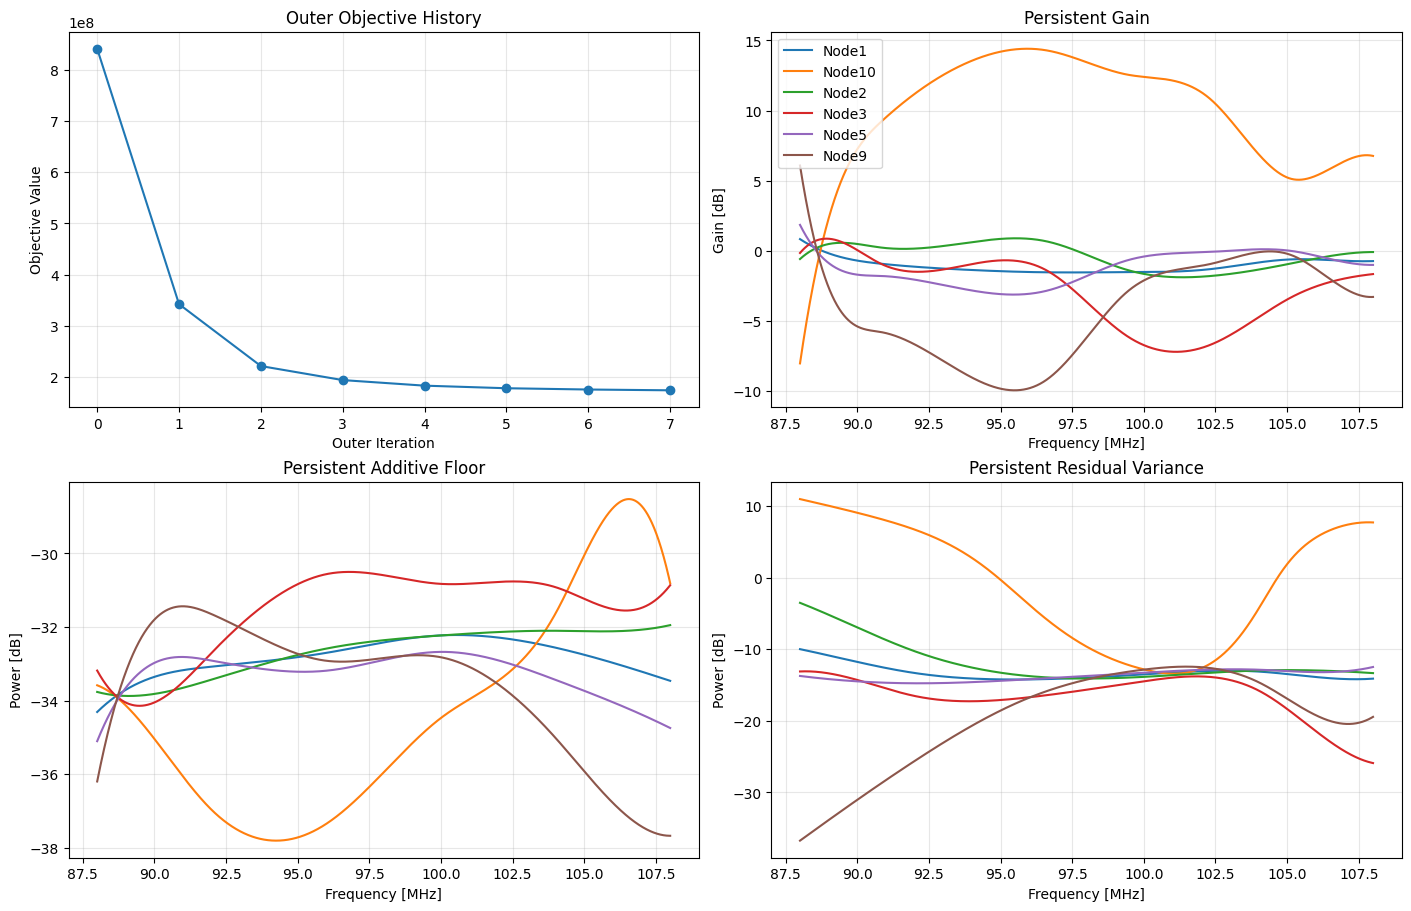

,sensor_id,mean_gain_db,mean_floor_db,mean_variance_db
0,Node1,-1.074743,-32.822662,-13.308133
1,Node10,9.746488,-34.307144,-0.958774
2,Node2,-0.358082,-32.665447,-11.933453
3,Node3,-2.841576,-31.566969,-16.520028
4,Node5,-1.241995,-33.272335,-13.723165
5,Node9,-4.230093,-33.606874,-19.551183


In [4]:
inspection_campaign = preparation.prepared_campaigns[0].campaign
frequency_mhz = inspection_campaign.frequency_hz / 1.0e6

fig, axes = plt.subplots(2, 2, figsize=(14, 9), constrained_layout=True)

axes[0, 0].plot(
    range(len(fit_result.result.objective_history)),
    fit_result.result.objective_history,
    marker="o",
)
axes[0, 0].set_title("Outer Objective History")
axes[0, 0].set_xlabel("Outer Iteration")
axes[0, 0].set_ylabel("Objective Value")
axes[0, 0].grid(alpha=0.3)

curve_rows = []
for sensor_id in fit_result.result.sensor_ids:
    curves = evaluate_persistent_calibration(
        result=fit_result.result,
        sensor_id=sensor_id,
        configuration=inspection_campaign.configuration,
        frequency_hz=inspection_campaign.frequency_hz,
    )
    axes[0, 1].plot(frequency_mhz, power_linear_to_db(curves.gain_power), label=sensor_id)
    axes[1, 0].plot(
        frequency_mhz,
        power_linear_to_db(curves.additive_noise_power),
        label=sensor_id,
    )
    axes[1, 1].plot(
        frequency_mhz,
        power_linear_to_db(curves.residual_variance_power2),
        label=sensor_id,
    )
    curve_rows.append(
        {
            "sensor_id": sensor_id,
            "mean_gain_db": float(power_linear_to_db(curves.gain_power).mean()),
            "mean_floor_db": float(power_linear_to_db(curves.additive_noise_power).mean()),
            "mean_variance_db": float(power_linear_to_db(curves.residual_variance_power2).mean()),
        }
    )

axes[0, 1].set_title("Persistent Gain")
axes[0, 1].set_xlabel("Frequency [MHz]")
axes[0, 1].set_ylabel("Gain [dB]")
axes[0, 1].grid(alpha=0.3)
axes[0, 1].legend(loc="best")

axes[1, 0].set_title("Persistent Additive Floor")
axes[1, 0].set_xlabel("Frequency [MHz]")
axes[1, 0].set_ylabel("Power [dB]")
axes[1, 0].grid(alpha=0.3)

axes[1, 1].set_title("Persistent Residual Variance")
axes[1, 1].set_xlabel("Frequency [MHz]")
axes[1, 1].set_ylabel("Power [dB]")
axes[1, 1].grid(alpha=0.3)

plt.show()

display(pd.DataFrame(curve_rows).sort_values("sensor_id"))